In [1]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage , SystemMessage
llm = init_chat_model(
    # "gemini-3.1-flash-lite-preview", 
    "gemini-2.5-flash",
    model_provider="google_genai",
    temperature=0 
)
from langchain.tools import tool

@tool(
    "calculator",
    description="A calculator tool that can be used to perform mathematical calculations. It takes a mathematical expression as input and returns the result of the calculation."
)
def calculator(expression: str) -> str:
    """It takes a mathematical expression as input and returns the result of the calculation."""
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"
    

from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="general",
    
)


import pydantic

class format(pydantic.BaseModel):
    """format for every reply """
    Title: str = pydantic.Field(description="The title for this coversation in less tahn 7 wrords ")
    tools_used : str = pydantic.Field(description="The tools you used in this conversation")
    answer: str = pydantic.Field(description="The answer to the user's question in less than 3 lines ")


from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[tavily_tool, calculator],
    system_prompt="You are a helpful ai",
    response_format=format
)
rresponse = agent.invoke(
    {"messages": "What is the current news related to anthropic . And then Calculate 5 * pi * pi * 7 *7 "}
)
rresponse

    


c:\DEV\devilcode development\Langchain-part2\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


{'messages': [HumanMessage(content='What is the current news related to anthropic . And then Calculate 5 * pi * pi * 7 *7 ', additional_kwargs={}, response_metadata={}, id='128a7c6d-2a79-4bb1-87a3-418e21168263'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'calculator', 'arguments': '{"expression": "5 * pi * pi * 7 * 7"}'}, '__gemini_function_call_thought_signatures__': {'3537873f-167a-4ee9-85ee-1d8ac739d224': 'Cq4GAQw51sfdcceFbwVzgEvGa3DmveEjjYTVJXgDhWz6HRTzSPyTurZaW8hHxdGXSf14Jvx8KDCJ5HeuznB6Rr0zLQpxwBBnid4YxUR7+f++dbHo/O2yq8/w6L5+Aduur5jWwOX+TCBH1QDy1XoNblg1AT9JMiJqPl0OQGbVjnwoBKsaITmZ6XGK6DTKgXBLOAz8ihhch6UnVBjqoiAtZ1N1poGqd99ChWCEWWX2qi3fEmfuOA/mCYA4tlldV7sWpdmNpGtPLbjvrxbojmyUUCLsIuT93HmmmHE3lRM2ejUml2AWVAKNKAovmm1CM03gzTeQbMfKAumhyI3hTpNUmY15wv2AHfmjvu9279g7/fH6JS21UwDotjHg/VIrADSBp9Ju9+LF/eoKWnPCIYT3xQgEf3XscCMlEw1OEg835JFGeeV6LrV3jcwkg7jev9EvQEPPrDvyCrCaRN/uNqltbGtB8u1EKINqb+ADy3kjsDAeIZ1oBKxjOjyPBNKALxfPqmMqDI9jFFUxmYgedK0JvPAkByscaoQlGGkEvsoyRbeZpSA8

In [2]:
# 1. Extract the Pydantic object from the agent's full response
final_output = rresponse["structured_response"]

# 2. You can access the individual fields using dot notation!
print("TITLE: ", final_output.Title)
print("TOOLS: ", final_output.tools_used)
print("ANSWER:", final_output.answer)

TITLE:  Anthropic News & Calculation
TOOLS:  tavily_search, calculator
ANSWER: Anthropic recently met with the White House and released Claude Opus 4.7. They are also involved in a lawsuit with the US Department of Defense. The calculation of 5 * pi * pi * 7 * 7 is approximately 2418.05.


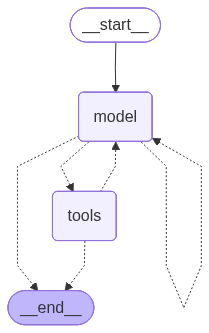

In [3]:
agent